 # Membros da equipe
| Alunos | Matrícula |
| :--- | :--- |
| **Victor Wangles Fernandes Bezerra** | 582233 |
| **Priscila Maria Campos de Oliveira** | 581336 |
| **Arthur Thome Costa** | 565756 |
| **Caio Emanuel Barbosa Silva** | 577886 |

In [70]:
#@title Instalando bibliotecas
!pip install pgmpy matplotlib networkx numpy pandas

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Estados legíveis reutilizados em quase todas as variáveis:
ESTADOS = ['Nao', 'Sim']
print("Bibliotecas importadas!")

Bibliotecas importadas!


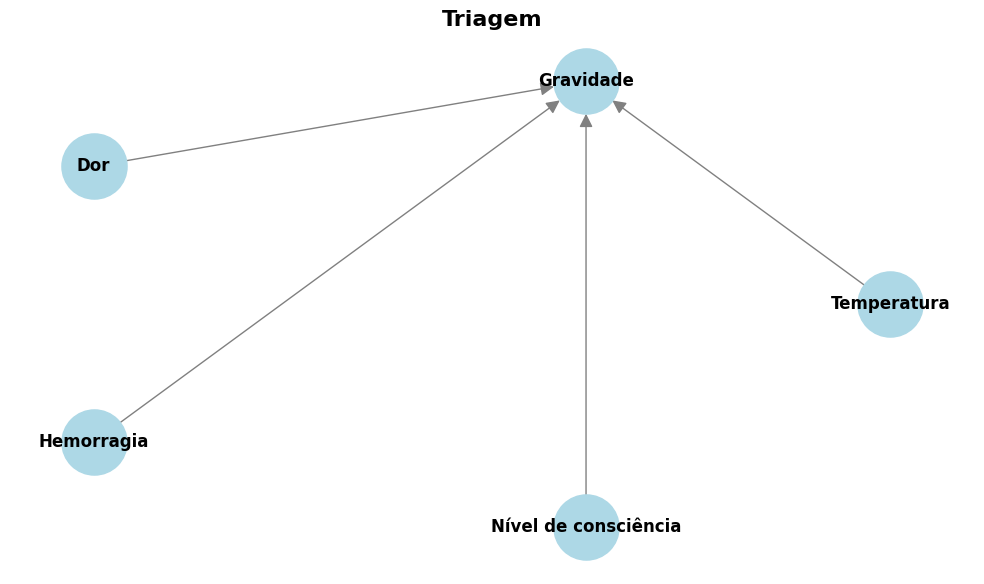

In [72]:
#@title Visualização da Rede

def visualizar_rede(modelo, titulo="Rede Bayesiana"):
    plt.figure(figsize=(10, 6))
    pos = nx.circular_layout(modelo)
    nx.draw_networkx_nodes(modelo, pos, node_color='lightblue', node_size=2200)
    nx.draw_networkx_edges(modelo, pos, edge_color='gray', arrows=True,
                           arrowstyle='-|>', arrowsize=20, node_size=2200)
    nx.draw_networkx_labels(modelo, pos, font_size=12, font_weight='bold')
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()

GRAVIDADE = ['Baixa', 'Média', 'Alta']
DOR = ['leve', 'moderada', 'severa']
HEMORRAGIA = ['controlável', 'incontrolável', 'sem hemorragia']
NIVEL_DE_CONSCIENCIA = ['leve', 'moderado', 'grave']
TEMPERATURA = ['baixa', 'normal', 'alta']

modelo_emergencia = DiscreteBayesianNetwork([
    ('Temperatura', 'Gravidade'),
    ('Dor', 'Gravidade'),
    ('Hemorragia', 'Gravidade'),
    ('Nível de consciência', 'Gravidade')
])

visualizar_rede(modelo_emergencia, "Triagem")

In [73]:
#@title Implementação dos CPDs

cpd_temperatura = TabularCPD(
    variable='Temperatura', variable_card=3,
    values=[[0.1],      # P(Temperatura=baixa)
            [0.6],      # P(Temperatura=normal)
            [0.3]],     # P(Temperatura=alta)
    state_names={'Temperatura': TEMPERATURA}
)
print(cpd_temperatura, '\n')

cpd_hemorragia = TabularCPD(
    variable='Hemorragia', variable_card=3,
    values=[[0.08],      # P(Hemorragia=controlável)
            [0.02],       # P(Hemorragia=incontrolável)
            [0.90]],     # P(Hemorragia=sem hemorragia)
    state_names={'Hemorragia': HEMORRAGIA}
)
print(cpd_hemorragia, '\n')

cpd_nivel_consciencia = TabularCPD(
    variable='Nivel de Consciência', variable_card=3,
    values=[[0.90],      # P(Nivel de Consciência=leve)
            [0.08],       # P(Nivel de Consciência=moderado)
            [0.02]],     # P(Nivel de Consciência=grave)
    state_names={'Nivel de Consciência': NIVEL_DE_CONSCIENCIA}
)
print(cpd_nivel_consciencia, '\n')

cpd_dor = TabularCPD(
    variable='Dor', variable_card=3,
    values=[[0.7],      # P(Dor=leve)
            [0.2],      # P(Dor=moderada)
            [0.1]],     # P(Dor=severa)
    state_names={'Dor': DOR}
)
print(cpd_dor, '\n')

+---------------------+-----+
| Temperatura(baixa)  | 0.1 |
+---------------------+-----+
| Temperatura(normal) | 0.6 |
+---------------------+-----+
| Temperatura(alta)   | 0.3 |
+---------------------+-----+ 

+----------------------------+------+
| Hemorragia(controlável)    | 0.08 |
+----------------------------+------+
| Hemorragia(incontrolável)  | 0.02 |
+----------------------------+------+
| Hemorragia(sem hemorragia) | 0.9  |
+----------------------------+------+ 

+--------------------------------+------+
| Nivel de Consciência(leve)     | 0.9  |
+--------------------------------+------+
| Nivel de Consciência(moderado) | 0.08 |
+--------------------------------+------+
| Nivel de Consciência(grave)    | 0.02 |
+--------------------------------+------+ 

+---------------+-----+
| Dor(leve)     | 0.7 |
+---------------+-----+
| Dor(moderada) | 0.2 |
+---------------+-----+
| Dor(severa)   | 0.1 |
+---------------+-----+ 



In [74]:
#@title Implementação CPD gravidade (4 Variáveis)

import itertools
import numpy as np
from pgmpy.factors.discrete import TabularCPD
from pgmpy.models import DiscreteBayesianNetwork

# -------------------------------------------------------------------------
# Apenas as 4 variáveis mantidas na rede
pais = ['Temperatura', 'Hemorragia', 'Nivel de Consciência', 'Dor']
cards_pais = [3, 3, 3, 3]

# Lista contendo as variáveis originais para acessar pelo índice do loop
estados_listas = [TEMPERATURA, HEMORRAGIA, NIVEL_DE_CONSCIENCIA, DOR]

valores_gravidade = [[], [], []]

# Varre as 81 combinações possíveis
for combinacao in itertools.product(*[range(card) for card in cards_pais]):

    # Extrai os sintomas reais da combinação atual
    temp = estados_listas[0][combinacao[0]]
    hemo = estados_listas[1][combinacao[1]]
    consc = estados_listas[2][combinacao[2]]
    dor_estado = estados_listas[3][combinacao[3]]

    # --- AVALIAÇÃO EXPLÍCITA DA POSSIBILIDADE ---

    # 1. Casos Críticos (Hemorragia incontrolável ou Consciência grave)
    if hemo == 'incontrolável' or consc == 'grave':
        p_baixa, p_media, p_alta = 0.01, 0.09, 0.90

    # 2. Casos Graves-Moderados (Duas condições perigosas simultâneas)
    elif (hemo == 'controlável' and consc == 'moderado') or (dor_estado == 'severa' and temp != 'normal'):
        p_baixa, p_media, p_alta = 0.05, 0.25, 0.70

    # 3. Estabilidade Perfeita (Paciente sem nenhuma alteração)
    elif temp == 'normal' and hemo == 'sem hemorragia' and consc == 'leve' and dor_estado == 'leve':
        p_baixa, p_media, p_alta = 0.98, 0.02, 0.00

    # 4. Casos Moderados Padrão (Sangramento controlável, alteração de consciência ou dor intensa)
    elif consc == 'moderado' or hemo == 'controlável' or dor_estado == 'severa':
        p_baixa, p_media, p_alta = 0.15, 0.75, 0.10

    # 5. Casos Leves com Atenção (Febre ou dor moderada)
    elif dor_estado == 'moderada' or temp != 'normal':
        p_baixa, p_media, p_alta = 0.60, 0.35, 0.05

    # 6. Demais Casos Leves (Sem anomalias significativas)
    else:
        p_baixa, p_media, p_alta = 0.85, 0.14, 0.01

    valores_gravidade[0].append(p_baixa)
    valores_gravidade[1].append(p_media)
    valores_gravidade[2].append(p_alta)

# Criação do CPD da Gravidade
cpd_gravidade = TabularCPD(
    variable='Gravidade',
    variable_card=3,
    values=np.array(valores_gravidade),
    evidence=pais,
    evidence_card=cards_pais,
    state_names={
        'Gravidade': GRAVIDADE,
        'Temperatura': TEMPERATURA,
        'Hemorragia': HEMORRAGIA,
        'Nivel de Consciência': NIVEL_DE_CONSCIENCIA,
        'Dor': DOR
    }
)

# Monta a estrutura final da Rede Bayesiana com os nomes corretos
modelo = DiscreteBayesianNetwork([
    ('Temperatura', 'Gravidade'),
    ('Hemorragia', 'Gravidade'),
    ('Nivel de Consciência', 'Gravidade'),
    ('Dor', 'Gravidade')
])

# Adiciona os 4 CPDs de sintomas + o CPD central de gravidade
modelo.add_cpds(
    cpd_temperatura,
    cpd_hemorragia,
    cpd_nivel_consciencia,
    cpd_dor,
    cpd_gravidade
)

# Validação estrutural
print("O modelo com 4 variáveis é válido?", modelo.check_model())

O modelo com 4 variáveis é válido? True


In [75]:
#@title Classe Paciente e A*

import heapq
import math
from typing import List, Tuple, Callable
import pandas as pd


class Paciente:
    def __init__(self, id_paciente: str, p_alta: float, tempo_espera_inicial: float):
        self.id = id_paciente
        self.p_alta = p_alta  # P(Gravidade = Alta) vinda da Rede Bayesianna
        self.tempo_espera = tempo_espera_inicial

    def calcular_risco(self, tempo_adicional: float, funcao_tempo: Callable[[float], float]) -> float:
        """Calcula o risco do paciente baseado no tempo total de espera."""
        tempo_total = self.tempo_espera + tempo_adicional
        return self.p_alta * funcao_tempo(tempo_total)

    def __repr__(self):
        return f"Paciente({self.id}, P_Alta={self.p_alta:.2f}, Espera={self.tempo_espera}min)"


class EstadoNo:
    """Representa um nó no espaço de estados do A*"""
    def __init__(self, pacientes_restantes: List[Paciente], ordem_atendimento: List[str],
                 tempo_decorrido: float, g_custo: float, h_custo: float):
        self.pacientes_restantes = pacientes_restantes
        self.ordem_atendimento = ordem_atendimento
        self.tempo_decorrido = tempo_decorrido
        self.g = g_custo  # Custo real acumulado até aqui
        self.h = h_custo  # Estimativa heurística do custo restante
        self.f = g_custo + h_custo

    def __lt__(self, outro: 'EstadoNo'):
        # Necessário para a fila de prioridades (heapq) escolher o menor 'f'
        return self.f < outro.f


def heuristica_admissivel(pacientes_restantes: List[Paciente], tempo_decorrido: float,
                          funcao_tempo: Callable[[float], float]) -> float:
    """
    Heurística h(n): Soma dos riscos atuais de todos os pacientes ainda na fila.
    Garante admissibilidade porque nunca superestima o custo real futuro.
    """
    return sum(p.calcular_risco(tempo_decorrido, funcao_tempo) for p in pacientes_restantes)


def busca_a_estrela(pacientes_iniciais: List[Paciente],
                     tempo_atendimento: float = 10.0,
                     tipo_funcao: str = 'linear',
                     tau: float = 1.0) -> Tuple[List[str], float]:
    """
    Executa o algoritmo A* para encontrar a ordem ótima de atendimento.
    """
    if tipo_funcao == 'linear':
        funcao_tempo = lambda t: t
    elif tipo_funcao == 'exponencial':
        funcao_tempo = lambda t: math.exp(t / tau)
    else:
        raise ValueError("Tipo de função inválido. Escolha 'linear' ou 'exponencial'.")

    h_inicial = heuristica_admissivel(pacientes_iniciais, 0.0, funcao_tempo)
    no_inicial = EstadoNo(
        pacientes_restantes=pacientes_iniciais,
        ordem_atendimento=[],
        tempo_decorrido=0.0,
        g_custo=0.0,
        h_custo=h_inicial
    )

    fila_prioridade = []
    heapq.heappush(fila_prioridade, no_inicial)

    while fila_prioridade:
        no_atual = heapq.heappop(fila_prioridade)

        if not no_atual.pacientes_restantes:
            return no_atual.ordem_atendimento, no_atual.g

        for i, paciente_escolhido in enumerate(no_atual.pacientes_restantes):

            novos_restantes = no_atual.pacientes_restantes[:i] + no_atual.pacientes_restantes[i+1:]
            nova_ordem = no_atual.ordem_atendimento + [paciente_escolhido.id]

            custo_acao = sum(p.calcular_risco(no_atual.tempo_decorrido, funcao_tempo) for p in novos_restantes)

            novo_tempo_decorrido = no_atual.tempo_decorrido + tempo_atendimento
            novo_g = no_atual.g + custo_acao
            novo_h = heuristica_admissivel(novos_restantes, novo_tempo_decorrido, funcao_tempo)

            no_filho = EstadoNo(
                pacientes_restantes=novos_restantes,
                ordem_atendimento=nova_ordem,
                tempo_decorrido=novo_tempo_decorrido,
                g_custo=novo_g,
                h_custo=novo_h
            )

            heapq.heappush(fila_prioridade, no_filho)

    return [], 0.0


def busca_a_estrela_df(df_pacientes: pd.DataFrame,
                       tempo_atendimento: float = 10.0,
                       tipo_funcao: str = 'linear',
                       tau: float = 1.0) -> Tuple[List[str], float]:
    """
    Executa o algoritmo A* lendo a probabilidade e o tempo de espera diretamente do DataFrame.
    """
    lista_pacientes_instanciados = []

    # 2. Converte as linhas do DataFrame em objetos da classe Paciente
    for _, linha in df_pacientes.iterrows():

        # Puxa o valor da inferência já realizada no momento da geração
        probabilidade_alta = linha['P_Alta']

        novo_paciente = Paciente(
            id_paciente=linha['ID'],
            p_alta=probabilidade_alta,
            tempo_espera_inicial=float(linha['Tempo_Espera_Inicial'])
        )

        lista_pacientes_instanciados.append(novo_paciente)

    ordem_pacientes_objetos, risco_total = busca_a_estrela_visual(lista_pacientes_instanciados, tempo_atendimento, tipo_funcao, tau)

    # 4. Formata a saída exibindo o valor numérico da Probabilidade Alta e o Tempo de Espera
    ordem_formatada = [
        f"{p.id} (P(Alta)={p.p_alta * 100:.1f}%, {int(p.tempo_espera)} min)"
        for p in ordem_pacientes_objetos
    ]

    return ordem_formatada, risco_total


def busca_a_estrela_visual(pacientes_iniciais: List[Paciente],
                           tempo_atendimento: float = 10.0,
                           tipo_funcao: str = 'linear',
                           tau: float = 1.0) -> Tuple[List[Paciente], float]:

    if tipo_funcao == 'linear':
        funcao_tempo = lambda t: t
    elif tipo_funcao == 'exponencial':
        funcao_tempo = lambda t: math.exp(t / tau)

    # Nova classe de Nó que guarda objetos na ordem de atendimento
    class EstadoNoVisual:
        def __init__(self, restantes: List[Paciente], ordem: List[Paciente], tempo: float, g: float, h: float):
            self.pacientes_restantes = restantes
            self.ordem_atendimento = ordem  # Agora guarda uma lista de objetos Paciente
            self.tempo_decorrido = tempo
            self.g = g
            self.h = h
            self.f = g + h
        def __lt__(self, outro):
            return self.f < outro.f

    h_inicial = heuristica_admissivel(pacientes_iniciais, 0.0, funcao_tempo)
    no_inicial = EstadoNoVisual(pacientes_iniciais, [], 0.0, 0.0, h_inicial)

    fila_prioridade = []
    heapq.heappush(fila_prioridade, no_inicial)

    while fila_prioridade:
        no_atual = heapq.heappop(fila_prioridade)

        if not no_atual.pacientes_restantes:
            return no_atual.ordem_atendimento, no_atual.g

        for i, paciente_escolhido in enumerate(no_atual.pacientes_restantes):
            novos_restantes = no_atual.pacientes_restantes[:i] + no_atual.pacientes_restantes[i+1:]

            # Mantém o objeto paciente na lista de ordem para podermos ler seus metadados no final
            nova_ordem = no_atual.ordem_atendimento + [paciente_escolhido]

            custo_acao = sum(p.calcular_risco(no_atual.tempo_decorrido, funcao_tempo) for p in novos_restantes)

            novo_tempo_decorrido = no_atual.tempo_decorrido + tempo_atendimento
            novo_g = no_atual.g + custo_acao
            novo_h = heuristica_admissivel(novos_restantes, novo_tempo_decorrido, funcao_tempo)

            no_filho = EstadoNoVisual(novos_restantes, nova_ordem, novo_tempo_decorrido, novo_g, novo_h)
            heapq.heappush(fila_prioridade, no_filho)

    return [], 0.0

In [76]:
import pandas as pd
import numpy as np
from pgmpy.inference import VariableElimination

def gerar_pacientes_aleatorios(n_pacientes: int, modelo_bayeseano) -> pd.DataFrame:
    """
    Gera um DataFrame de pacientes com sintomas aleatórios e já calcula
    a P(Gravidade = Alta) usando a Rede Bayesiana fornecida (4 variáveis).
    """
    np.random.seed(67)  # Define semente para reprodutibilidade dos testes

    # Extração das probabilidades dos CPDs declarados (apenas 4 variáveis)
    p_temperatura = cpd_temperatura.get_values().flatten()
    p_hemorragia = cpd_hemorragia.get_values().flatten()
    p_nivel_consciencia = cpd_nivel_consciencia.get_values().flatten()
    p_dor = cpd_dor.get_values().flatten()

    # Inicializa o motor de inferência
    inferencia = VariableElimination(modelo_bayeseano)

    dados_pacientes = []

    for idx in range(1, n_pacientes + 1):
        # 1. Sorteia os sintomas individualmente
        sintoma_temp = np.random.choice(TEMPERATURA, p=p_temperatura)
        sintoma_hemo = np.random.choice(HEMORRAGIA, p=p_hemorragia)
        sintoma_consc = np.random.choice(NIVEL_DE_CONSCIENCIA, p=p_nivel_consciencia)
        sintoma_dor = np.random.choice(DOR, p=p_dor)

        # 2. Prepara as evidências para a Rede Bayesiana
        evidencias = {
            'Temperatura': sintoma_temp,
            'Hemorragia': sintoma_hemo,
            'Nivel de Consciência': sintoma_consc,
            'Dor': sintoma_dor
        }

        # 3. Faz a inferência para descobrir a P(Alta)
        resultado = inferencia.query(variables=['Gravidade'], evidence=evidencias, show_progress=False)
        p_alta = resultado.get_value(Gravidade='Alta')

        # 4. Salva todas as informações consolidadas
        paciente = {
            'ID': f"Paciente_{idx:03d}",
            'Temperatura': sintoma_temp,
            'Hemorragia': sintoma_hemo,
            'Nivel de Consciência': sintoma_consc,
            'Dor': sintoma_dor,
            'Tempo_Espera_Inicial': float(np.random.randint(0, 41)),
            'P_Alta': p_alta  # Nova coluna com o valor da inferência
        }
        dados_pacientes.append(paciente)

    return pd.DataFrame(dados_pacientes)

In [77]:
def fila_fifo(df_pacientes: pd.DataFrame) -> List[str]:
    """
    Ordena pelo tempo de espera (quem chegou primeiro tem menor tempo de espera inicial).
    Retorna apenas a lista de IDs na ordem de atendimento.
    """
    # Ordena pelo tempo de espera de forma ascendente
    df_ordenado = df_pacientes.sort_values(by='Tempo_Espera_Inicial', ascending=True)
    return df_ordenado['ID'].tolist()

In [78]:
def fila_gulosa(df_pacientes: pd.DataFrame) -> List[str]:
    """
    Ordena pelo maior risco (P_Alta) de forma descendente.
    Retorna apenas a lista de IDs na ordem de atendimento.
    """
    # Ordena pelo P_Alta de forma descendente (maior risco primeiro)
    df_ordenado = df_pacientes.sort_values(by='P_Alta', ascending=False)
    return df_ordenado['ID'].tolist()

In [79]:
def calcular_custo_total(ordem_ids: List[str], df_pacientes: pd.DataFrame,
                         tempo_atendimento: float, tipo_funcao: str = 'linear') -> float:
    """Calcula o risco acumulado para uma ordem fixa de pacientes."""

    if tipo_funcao == 'linear':
        funcao = lambda t: t
    else:
        funcao = lambda t: math.exp(t / 1.0) # Considerando tau=1.0 fixo para simplificar

    custo_total = 0.0
    tempo_atual = 0.0

    # Cria lista de pacientes ordenados
    ordem_pacientes = [next(p for p in [Paciente(linha['ID'], linha['P_Alta'], linha['Tempo_Espera_Inicial'])
                                       for _, linha in df_pacientes.iterrows()] if p.id == id_p)
                       for id_p in ordem_ids]

    # Simula a fila
    restantes = ordem_pacientes.copy()
    for paciente_atendido in ordem_pacientes:
        restantes.remove(paciente_atendido)
        # O risco acumulado é a soma dos riscos de quem ficou esperando
        for p in restantes:
            custo_total += p.calcular_risco(tempo_atual, funcao)
        tempo_atual += tempo_atendimento

    return custo_total


In [81]:
# Exemplo Paciente Real: João ligou e sabemos que NÃO houve terremoto
inferencia_gravidade = VariableElimination(modelo)

resultado = inferencia_gravidade.query(
    variables=['Gravidade'],
    evidence={'Dor': 'leve'}
)
print("Paciente chegou com dor leve")
print("P(Gravidade | Dor=leve):")
print(resultado)
print()

Paciente chegou com dor leve
P(Gravidade | Dor=leve):
+------------------+------------------+
| Gravidade        |   phi(Gravidade) |
+==================+==================+
| Gravidade(Baixa) |           0.6930 |
+------------------+------------------+
| Gravidade(Média) |           0.2363 |
+------------------+------------------+
| Gravidade(Alta)  |           0.0707 |
+------------------+------------------+



In [85]:
if __name__ == "__main__":
    fila_pacientes = gerar_pacientes_aleatorios(5, modelo)
    tempo = 10.0

    print("--- Comparativo de Estratégias de Triagem ---")

    # 1. FIFO
    ordem_fifo = fila_fifo(fila_pacientes)
    custo_fifo = calcular_custo_total(ordem_fifo, fila_pacientes, tempo)
    print(f"\n[FIFO] Custo Total: {custo_fifo:.2f}")
    print(f"Sequência: \n{' -> \n'.join(ordem_fifo)}")

    # 2. Gulosa
    ordem_gulosa = fila_gulosa(fila_pacientes)
    custo_gulosa = calcular_custo_total(ordem_gulosa, fila_pacientes, tempo)
    print(f"\n[Gulosa] Custo Total: {custo_gulosa:.2f}")
    print(f"Sequência: \n{' -> \n'.join(ordem_gulosa)}")

    # 3. A*
    # Nota: busca_a_estrela_df retorna uma lista de strings formatadas
    ordem_otima_formatada, custo_total_a_estrela = busca_a_estrela_df(fila_pacientes, tempo_atendimento=tempo)

    # Extrair apenas IDs para a sequência simplificada (opcional)
    ids_a_estrela = [item.split(' ')[0] for item in ordem_otima_formatada]

    print(f"\n[A*] Custo Total: {custo_total_a_estrela:.2f}")
    print(f"Sequência: \n{' -> \n'.join(ids_a_estrela)}")

    # Comparativo final
    print(f"\n" + "="*50)
    print(f"Redução de risco (A* vs FIFO): "
          f"{((custo_fifo - custo_total_a_estrela) / custo_fifo) * 100:.1f}%")

--- Comparativo de Estratégias de Triagem ---

[FIFO] Custo Total: 163.80
Sequência: 
Paciente_003 -> 
Paciente_002 -> 
Paciente_001 -> 
Paciente_004 -> 
Paciente_005

[Gulosa] Custo Total: 28.30
Sequência: 
Paciente_002 -> 
Paciente_005 -> 
Paciente_003 -> 
Paciente_001 -> 
Paciente_004

[A*] Custo Total: 24.10
Sequência: 
Paciente_005 -> 
Paciente_002 -> 
Paciente_003 -> 
Paciente_001 -> 
Paciente_004

Redução de risco (A* vs FIFO): 85.3%


In [89]:
if __name__ == "__main__":
    fila_pacientes = gerar_pacientes_aleatorios(20, modelo)
    tempo = 10.0

    print("--- Comparativo de Estratégias de Triagem ---")

    # 1. FIFO
    ordem_fifo = fila_fifo(fila_pacientes)
    custo_fifo = calcular_custo_total(ordem_fifo, fila_pacientes, tempo)
    print(f"\n[FIFO] Custo Total: {custo_fifo:.2f}")
    print(f"Sequência: \n{' -> \n'.join(ordem_fifo)}")

    # 2. Gulosa
    ordem_gulosa = fila_gulosa(fila_pacientes)
    custo_gulosa = calcular_custo_total(ordem_gulosa, fila_pacientes, tempo)
    print(f"\n[Gulosa] Custo Total: {custo_gulosa:.2f}")
    print(f"Sequência: \n{' -> \n'.join(ordem_gulosa)}")

    # 3. A*
    # Nota: busca_a_estrela_df retorna uma lista de strings formatadas
    ordem_otima_formatada, custo_total_a_estrela = busca_a_estrela_df(fila_pacientes, tempo_atendimento=tempo)

    # Extrair apenas IDs para a sequência simplificada (opcional)
    ids_a_estrela = [item.split(' ')[0] for item in ordem_otima_formatada]

    print(f"\n[A*] Custo Total: {custo_total_a_estrela:.2f}")
    print(f"Sequência: \n{' -> \n'.join(ids_a_estrela)}")

    # Comparativo final
    print(f"\n" + "="*50)
    print(f"Redução de risco (A* vs FIFO): "
          f"{((custo_fifo - custo_total_a_estrela) / custo_fifo) * 100:.1f}%")

--- Comparativo de Estratégias de Triagem ---

[FIFO] Custo Total: 3622.90
Sequência: 
Paciente_020 -> 
Paciente_009 -> 
Paciente_016 -> 
Paciente_011 -> 
Paciente_012 -> 
Paciente_006 -> 
Paciente_017 -> 
Paciente_014 -> 
Paciente_018 -> 
Paciente_013 -> 
Paciente_015 -> 
Paciente_003 -> 
Paciente_008 -> 
Paciente_002 -> 
Paciente_019 -> 
Paciente_004 -> 
Paciente_001 -> 
Paciente_005 -> 
Paciente_010 -> 
Paciente_007

[Gulosa] Custo Total: 350.25
Sequência: 
Paciente_008 -> 
Paciente_002 -> 
Paciente_005 -> 
Paciente_009 -> 
Paciente_019 -> 
Paciente_015 -> 
Paciente_003 -> 
Paciente_013 -> 
Paciente_018 -> 
Paciente_010 -> 
Paciente_011 -> 
Paciente_007 -> 
Paciente_014 -> 
Paciente_001 -> 
Paciente_004 -> 
Paciente_006 -> 
Paciente_012 -> 
Paciente_016 -> 
Paciente_017 -> 
Paciente_020

[A*] Custo Total: 337.80
Sequência: 
Paciente_005 -> 
Paciente_008 -> 
Paciente_002 -> 
Paciente_009 -> 
Paciente_019 -> 
Paciente_015 -> 
Paciente_007 -> 
Paciente_010 -> 
Paciente_003 -> 
Paciente